In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from mergedownloader.downloader import Downloader
from mergedownloader.file_downloader import FileDownloader, ConnectionType, DownloadMode
from mergedownloader.inpeparser import INPE_SERVER, InpeParsers, InpeTypes
from rainreporter.reporter import Reporter
from mergedownloader.utils import DateProcessor

In [3]:
# Create a Downloader instance
fd = FileDownloader(
server=INPE_SERVER, 
connection_type=ConnectionType.HTTP,
download_mode=DownloadMode.NO_UPDATE
)

downloader = Downloader(
file_downloader=fd,
local_folder='/workspaces/reports_folder/downloads',
parsers=InpeParsers
)

Using wget through HTTP on: ftp.cptec.inpe.br


In [4]:
reporter = Reporter(
    downloader=downloader,
    config_file='/workspaces/RainReporter/reporter.json5',
    bases_folder='/workspaces/reports_folder/bases',
)

../data/cities/cidades.shp
../data/states/BR_UF_2022.shp
../data/rivers/main_rivers.shp
../data/dams


In [13]:
reporter.generate_pdf(
    json_file='/workspaces/reports_folder/configs/guaiba.json5',
    output_folder="/workspaces/reports_folder/output",
)


In [11]:
reporter.process_folder(
    input_folder='/workspaces/reports_folder/configs',
    output_folder="/workspaces/reports_folder/output",
)


## Daily Report

In [8]:
from rainreporter.daily_report import DailyReport

In [9]:
daily_reporter = DailyReport.from_dict(
    downloader=downloader,
    mapper=reporter.mapper,
    config= {
        "nome": "Uruguai - Diario",
        "tipo": "Diario",
        "shp": "bacias_interesse/bacia_Uruguai.shp",
    },
    bases_folder='/workspaces/reports_folder/bases',
)

In [11]:
report = daily_reporter.generate_report("2025-06-27")

/usr/local/lib/python3.10/dist-packages/ecmwflibs/__init__.py:81: UserWarning: libglib-2.0.so.0: cannot open shared object file: No such file or directory
  warnings.warn(str(e))


AttributeError: DAILY_WRF

## Comparing MLTs

In [17]:
old_mlt_path = "/workspaces/reports_folder/downloads2/MONTHLY_ACCUMULATED"
new_mlt_path = "/workspaces/reports_folder/downloads/MONTHLY_ACCUMULATED"
month = "feb"
filename = f'MERGE_CPTEC_acum_{month}.nc'

In [18]:
import xarray as xr

In [19]:
old_mlt = xr.open_dataset(f"{old_mlt_path}/{filename}")
new_mlt = xr.open_dataset(f"{new_mlt_path}/{filename}")

In [28]:
old_mlt["precacum"].mean().data, new_mlt["precacum"].mean().data

(array(116.87978213), array(101.23465854))

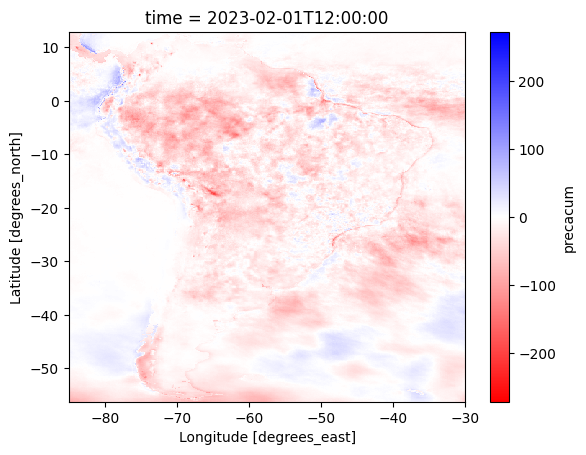

In [39]:
(new_mlt["precacum"] - old_mlt["precacum"]).plot(cmap="bwr_r")

In [35]:
import matplotlib.pyplot as plt

In [32]:
%matplotlib inline

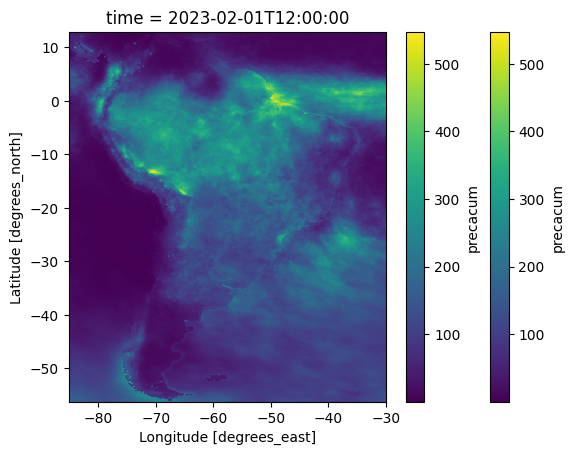

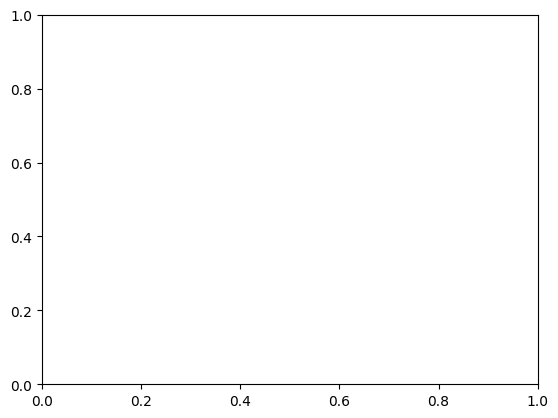

In [36]:
fig, ax = plt.subplots()